# Choice-Based Conjoint Analysis of Netflix Subscription Preferences

## Libraries and Data

In [2]:
#Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import squarify

In [3]:
#Load the data
df = pd.read_csv('../data/netflix_customer_survey.csv')
df.head()

,customerid,NumberAccounts,price,ExtraContent,ads,selected
0,7,2,10,HBO,one_per_day,1
1,7,6,8,Marvel,one_per_show,1
2,7,4,15,Disney,one_per_day,1
3,7,5,10,HBO,one_per_day,1
4,7,1,20,Soccer,one_per_show,1


In [4]:
#Data Overview
print(df.shape)
df.info()
df.describe()

(3000, 6)
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      3000 non-null   int64
 1   NumberAccounts  3000 non-null   int64
 2   price           3000 non-null   int64
 3   ExtraContent    3000 non-null   str  
 4   ads             3000 non-null   str  
 5   selected        3000 non-null   int64
dtypes: int64(4), str(2)
memory usage: 140.8 KB


,customerid,NumberAccounts,price,selected
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,454.129333,3.589000,13.769000,0.498000
std,254.410396,1.726385,4.225351,0.500079
min,7.000000,1.000000,8.000000,0.000000
25%,237.000000,2.000000,10.000000,0.000000
50%,449.000000,4.000000,12.000000,0.000000
75%,669.000000,5.000000,18.000000,1.000000
max,900.000000,6.000000,20.000000,1.000000


## Data Processing

In [5]:
#Split Features and Target

#Target variable
y = df['selected']

#Feature variables
X = df.drop(columns = ['selected', 'customerid'])

#Preview the features
X.head()

,NumberAccounts,price,ExtraContent,ads
0,2,10,HBO,one_per_day
1,6,8,Marvel,one_per_show
2,4,15,Disney,one_per_day
3,5,10,HBO,one_per_day
4,1,20,Soccer,one_per_show


In [6]:
#Create dummy Variables
X_dummy = pd.get_dummies(X, columns = X.columns)

#Convert boolean columns to integers
X_dummy = X_dummy.astype(int)

#Preview transformed features
X_dummy.head()

,NumberAccounts_1,NumberAccounts_2,NumberAccounts_3,NumberAccounts_4,NumberAccounts_5,NumberAccounts_6,price_8,price_10,price_12,price_15,...,price_20,ExtraContent_Disney,ExtraContent_HBO,ExtraContent_Marvel,ExtraContent_Prime originals,ExtraContent_Soccer,ExtraContent_less content,ads_none,ads_one_per_day,ads_one_per_show
0,0,1,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0
1,0,0,0,0,0,1,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,0,0,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,1,0
3,0,0,0,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0
4,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1


## Regression Model

In [7]:
#Build Logistic Regression Model

model = sm.GLM(y,
               X_dummy,
               family = sm.families.Binomial()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               selected   No. Observations:                 3000
Model:                            GLM   Df Residuals:                     2982
Model Family:                Binomial   Df Model:                           17
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1948.3
Date:                Thu, 07 May 2026   Deviance:                       3896.6
Time:                        18:24:42   Pearson chi2:                 3.00e+03
No. Iterations:                   100   Pseudo R-squ. (CS):            0.08371
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
NumberAccounts_1                -0.7035      0.090     -7.808      0.000      -0.880      -0.527
NumberAccounts_2                -0.0735      0.088     -0.832      0.406      -0.247       0.100
NumberAccounts_3                -0.0221      0.088     -0.251      0.801      -0.194       0.150
NumberAccounts_4                 0.1248      0.084      1.494      0.135      -0.039       0.289
NumberAccounts_5                 0.1318      0.084      1.560      0.119      -0.034       0.297
NumberAccounts_6                 0.4966      0.083      6.019      0.000       0.335       0.658
price_8                          0.2965      0.085      3.488      0.000       0.130       0.463
price_10                         0.2200      0.087      2.520      0.012       0.049       0.391
price_12                         0.2015      0.082      2.446      0.014       0.040       0.363
price_15                         0.0196      0.084      0.232      0.816      -0.145       0.185
price_18                        -0.1029      0.087     -1.183      0.237      -0.273       0.068
price_20                        -0.6804      0.091     -7.515      0.000      -0.858      -0.503
ExtraContent_Disney              0.2284      0.088      2.607      0.009       0.057       0.400
ExtraContent_HBO                 0.2258      0.086      2.632      0.008       0.058       0.394
ExtraContent_Marvel              0.1449      0.084      1.728      0.084      -0.019       0.309
ExtraContent_Prime originals     0.1276      0.086      1.480      0.139      -0.041       0.297
ExtraContent_Soccer             -0.2043      0.085     -2.407      0.016      -0.371      -0.038
ExtraContent_less content       -0.5681      0.087     -6.497      0.000      -0.740      -0.397
ads_none                         0.2076      0.056      3.740      0.000       0.099       0.316
ads_one_per_day                  0.1088      0.056      1.927      0.054      -0.002       0.219
ads_one_per_show                -0.3622      0.057     -6.367      0.000      -0.474      -0.251
================================================================================================
"""

## Conjoint Analysis

In [8]:
#Part-worth utilities
df_results = pd.DataFrame({'attribute': model.params.index,
                          'partworth_utility': model.params.values,
                          'p_value': model.pvalues.values})
df_results.head()

,attribute,partworth_utility,p_value
0,NumberAccounts_1,-0.703499,5.823997e-15
1,NumberAccounts_2,-0.073491,4.055497e-01
2,NumberAccounts_3,-0.022052,8.014421e-01
3,NumberAccounts_4,0.124826,1.351002e-01
4,NumberAccounts_5,0.131801,1.186565e-01


In [9]:
#Statistical Significance
df_results['significant'] = df_results['p_value'] < 0.05

#Color significant variables
df_results['color'] = df_results['significant'].map({True: 'blue', False: 'red'})
df_results.head()

,attribute,partworth_utility,p_value,significant,color
0,NumberAccounts_1,-0.703499,5.823997e-15,True,blue
1,NumberAccounts_2,-0.073491,4.055497e-01,False,red
2,NumberAccounts_3,-0.022052,8.014421e-01,False,red
3,NumberAccounts_4,0.124826,1.351002e-01,False,red
4,NumberAccounts_5,0.131801,1.186565e-01,False,red


In [10]:
#Sort results
df_results = df_results.sort_values(by = 'partworth_utility', ascending = True)
df_results.head()

,attribute,partworth_utility,p_value,significant,color
0,NumberAccounts_1,-0.703499,5.823997e-15,True,blue
11,price_20,-0.680442,5.698844e-14,True,blue
17,ExtraContent_less content,-0.568143,8.207307e-11,True,blue
20,ads_one_per_show,-0.362189,1.929704e-10,True,blue
16,ExtraContent_Soccer,-0.204343,1.608159e-02,True,blue


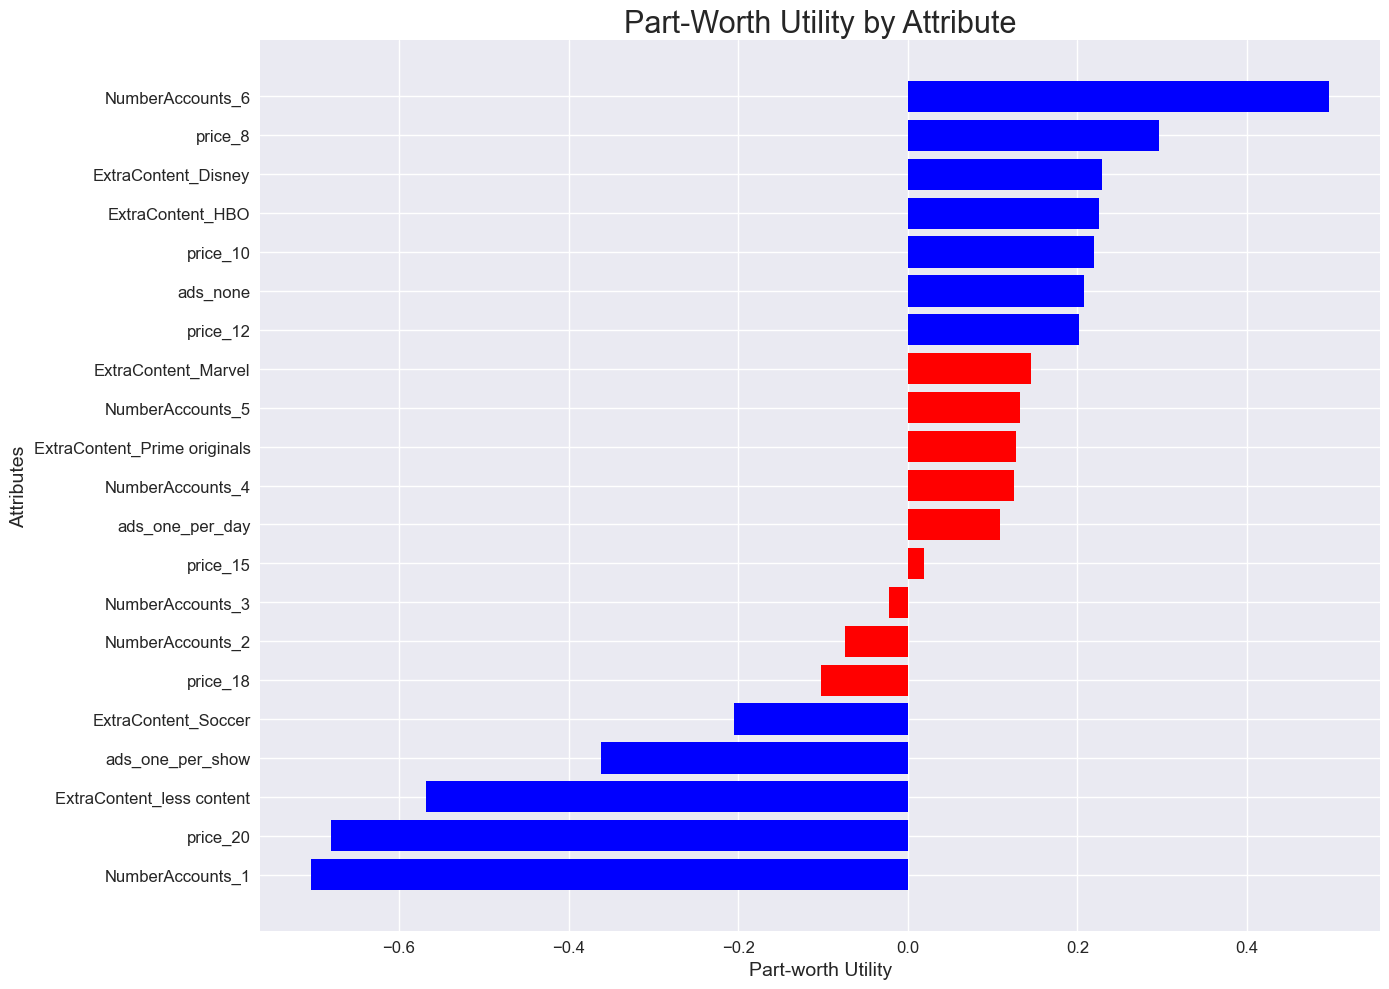

In [11]:
import matplotlib.pyplot as plt

#Apply chart style
plt.style.use('seaborn-v0_8')

#Part-worth Visualization
plt.figure(figsize = (14, 10))

plt.barh(df_results['attribute'],
         df_results['partworth_utility'],
         color = df_results['color'])

plt.title('Part-Worth Utility by Attribute', fontsize = 22)

plt.xlabel('Part-worth Utility', fontsize = 14)
plt.ylabel('Attributes', fontsize = 14)

plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

plt.tight_layout()

plt.savefig('../visuals/partworth_utility_by_attribute.png',
            bbox_inches='tight',
            dpi=300)

plt.show()

## Specific groups of Features

In [12]:
#Feature Group Analysis
feature_name = "price"
attributes = []
utilities = []

for i in range(len(df_results)):
  attribute_name = df_results.iloc[i]['attribute']
  if attribute_name.startswith(feature_name):
    attributes.append(attribute_name)
    utilities.append(df_results.iloc[i]['partworth_utility'])

#Preview extracted values
print(attributes)
print(utilities)

['price_20', 'price_18', 'price_15', 'price_12', 'price_10', 'price_8']
[np.float64(-0.6804415974275324), np.float64(-0.10287290531239401), np.float64(0.019553126031692628), np.float64(0.20149057135414533), np.float64(0.22002390568325952), np.float64(0.29648049880660315)]


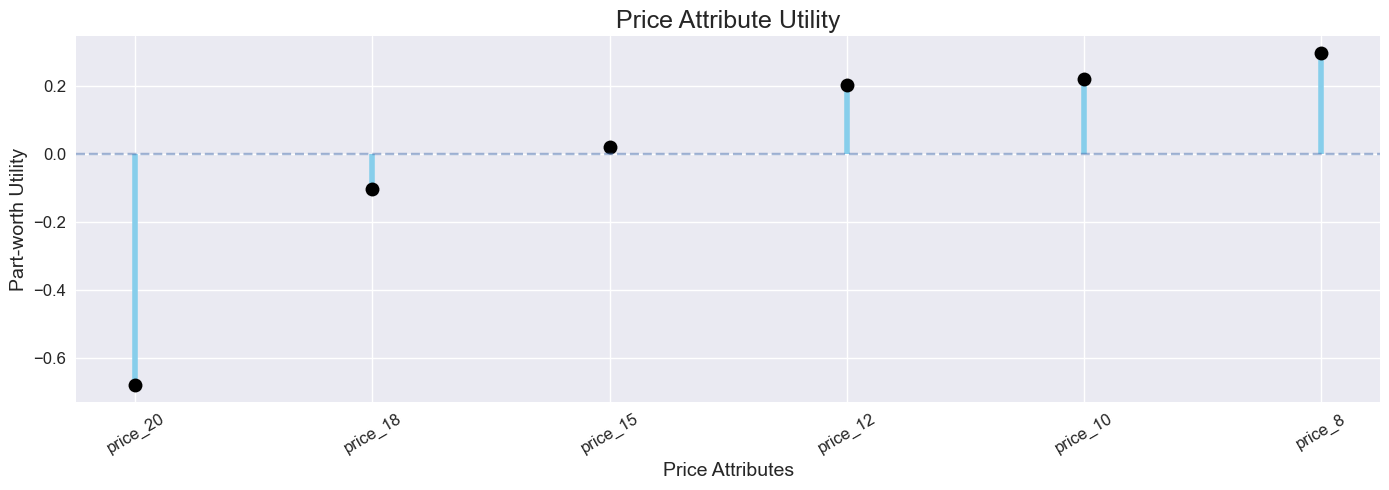

In [13]:
import matplotlib.pyplot as plt

#Lollipop chart for price attributes

plt.figure(figsize = (14, 5))

markers, stems, baseline = plt.stem(attributes,
                                    utilities,
                                    linefmt = '-',
                                    markerfmt = 'o',
                                    basefmt = ' ')

#Customize appearance
plt.setp(stems, color = "skyblue", linewidth = 4)
plt.setp(markers, color = "black", markersize = 10)

#Titles and labels
plt.title('Price Attribute Utility', fontsize = 18)

plt.xlabel('Price Attributes', fontsize = 14)
plt.ylabel('Part-worth Utility', fontsize = 14)

#Axis formatting
plt.xticks(rotation = 30, fontsize = 12)
plt.yticks(fontsize = 12)

#Add horizontal reference line
plt.axhline(y=0, linestyle='--', alpha=0.5)

#Layout optimization
plt.tight_layout()

plt.savefig('../visuals/price_attribute_utility.png',
            bbox_inches='tight',
            dpi=300)

plt.show()

## Feature Importance

In [14]:
#Feature Importance
features_partworth = {}

for key, coeff in model.params.items():
    feature = key.split('_', 1)[0]

    if feature not in features_partworth:
        features_partworth[feature] = []
    
    features_partworth[feature].append(coeff)

features_partworth

{'NumberAccounts': [-0.703498668143441,
  -0.07349080797575133,
  -0.022052425413520822,
  0.12482590952124067,
  0.13180110092424657,
  0.4966484902229996],
 'price': [0.29648049880660315,
  0.22002390568325952,
  0.20149057135414533,
  0.019553126031692628,
  -0.10287290531239401,
  -0.6804415974275324],
 'ExtraContent': [0.22838575765881292,
  0.2257925210169405,
  0.14490084468487155,
  0.12764068227644718,
  -0.2043433534067961,
  -0.5681428530945021],
 'ads': [0.20761937228935534, 0.10880343281823059, -0.36218920597181115]}

In [15]:
#Compute Importance per feature
importance_per_feature = {k: max(v) - min(v) for k, v in features_partworth.items()}
importance_per_feature

{'NumberAccounts': 1.2001471583664407,
 'price': 0.9769220962341356,
 'ExtraContent': 0.7965286107533149,
 'ads': 0.5698085782611665}

In [16]:
#Computing the sum of importances
total_importance = sum(importance_per_feature.values())
total_importance

3.5434064436150576

In [17]:
#Relative importance (adds up to 100)
relative_importance = {k: round(100 * v / total_importance, 1)
                       for k, v in importance_per_feature.items()}
relative_importance

{'NumberAccounts': 33.9, 'price': 27.6, 'ExtraContent': 22.5, 'ads': 16.1}

In [18]:
#Convert to DataFrame (DF)
df_importance = pd.DataFrame(
    list(relative_importance.items()),
    columns = ['feature', 'relative_importance'])
df_importance

,feature,relative_importance
0,NumberAccounts,33.9
1,price,27.6
2,ExtraContent,22.5
3,ads,16.1


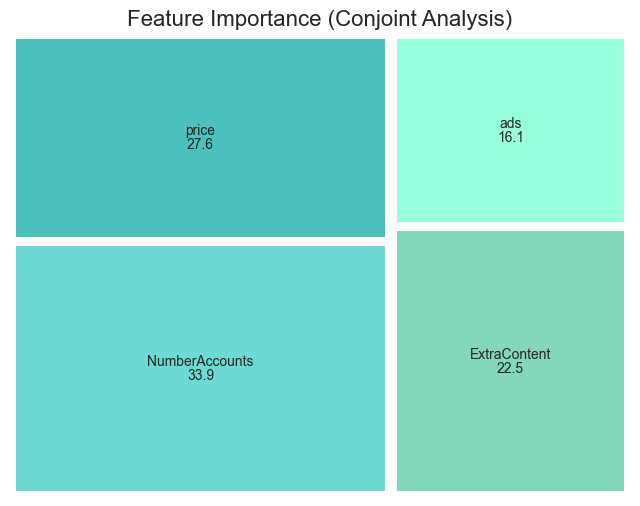

In [19]:
#Treemap 

plt.figure(figsize = (8, 6))

squarify.plot(sizes = df_importance['relative_importance'],
              label = df_importance['feature'],
              color = ['mediumturquoise', 'lightseagreen', 'mediumaquamarine', 'aquamarine'],
              value = df_importance['relative_importance'],
              alpha = 0.8,
              pad = True)

plt.axis('off')
plt.title('Feature Importance (Conjoint Analysis)', fontsize = 16)
plt.show()

## Interaction Terms

In [20]:
#Create Interaction Feature
df['content_ads'] = df['ExtraContent'] + "_" + df['ads']
df.head()

,customerid,NumberAccounts,price,ExtraContent,ads,selected,content_ads
0,7,2,10,HBO,one_per_day,1,HBO_one_per_day
1,7,6,8,Marvel,one_per_show,1,Marvel_one_per_show
2,7,4,15,Disney,one_per_day,1,Disney_one_per_day
3,7,5,10,HBO,one_per_day,1,HBO_one_per_day
4,7,1,20,Soccer,one_per_show,1,Soccer_one_per_show


In [21]:
#Drop the original columns
df_interaction = df.drop(columns = ['ExtraContent', 'ads'])
df_interaction.head()

,customerid,NumberAccounts,price,selected,content_ads
0,7,2,10,1,HBO_one_per_day
1,7,6,8,1,Marvel_one_per_show
2,7,4,15,1,Disney_one_per_day
3,7,5,10,1,HBO_one_per_day
4,7,1,20,1,Soccer_one_per_show


In [22]:
#Split Data
y = df_interaction['selected']
X = df_interaction.drop(columns = ['selected', 'customerid'])
X.head()

,NumberAccounts,price,content_ads
0,2,10,HBO_one_per_day
1,6,8,Marvel_one_per_show
2,4,15,Disney_one_per_day
3,5,10,HBO_one_per_day
4,1,20,Soccer_one_per_show


In [23]:
#Dummy encoding
X_dummy = pd.get_dummies(X)
X_dummy = X_dummy.astype(int)
X_dummy.head()

,NumberAccounts,price,content_ads_Disney_none,content_ads_Disney_one_per_day,content_ads_Disney_one_per_show,content_ads_HBO_none,content_ads_HBO_one_per_day,content_ads_HBO_one_per_show,content_ads_Marvel_none,content_ads_Marvel_one_per_day,content_ads_Marvel_one_per_show,content_ads_Prime originals_none,content_ads_Prime originals_one_per_day,content_ads_Prime originals_one_per_show,content_ads_Soccer_none,content_ads_Soccer_one_per_day,content_ads_Soccer_one_per_show,content_ads_less content_none,content_ads_less content_one_per_day,content_ads_less content_one_per_show
0,2,10,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,6,8,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,4,15,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,5,10,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [24]:
#Build second model
model2 = sm.GLM(y,
               X_dummy,
               family = sm.families.Binomial()).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               selected   No. Observations:                 3000
Model:                            GLM   Df Residuals:                     2980
Model Family:                Binomial   Df Model:                           19
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1956.2
Date:                Thu, 07 May 2026   Deviance:                       3912.5
Time:                        18:24:45   Pearson chi2:                 3.00e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.07883
Covariance Type:            nonrobust                                         
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
NumberAccounts                               0.1941      0.022      8.674      0.000       0.150       0.238
price                                       -0.0686      0.009     -7.539      0.000      -0.086      -0.051
content_ads_Disney_none                      0.5857      0.214      2.734      0.006       0.166       1.006
content_ads_Disney_one_per_day               0.7852      0.229      3.427      0.001       0.336       1.234
content_ads_Disney_one_per_show              0.0808      0.218      0.371      0.710      -0.346       0.507
content_ads_HBO_none                         0.7930      0.221      3.590      0.000       0.360       1.226
content_ads_HBO_one_per_day                  0.7673      0.218      3.517      0.000       0.340       1.195
content_ads_HBO_one_per_show                -0.0847      0.220     -0.385      0.700      -0.515       0.346
content_ads_Marvel_none                      0.4944      0.217      2.277      0.023       0.069       0.920
content_ads_Marvel_one_per_day               0.4361      0.221      1.970      0.049       0.002       0.870
content_ads_Marvel_one_per_show              0.1913      0.212      0.903      0.367      -0.224       0.607
content_ads_Prime originals_none             0.5123      0.217      2.364      0.018       0.087       0.937
content_ads_Prime originals_one_per_day      0.3680      0.213      1.724      0.085      -0.050       0.786
content_ads_Prime originals_one_per_show     0.2460      0.224      1.098      0.272      -0.193       0.685
content_ads_Soccer_none                      0.3835      0.218      1.755      0.079      -0.045       0.812
content_ads_Soccer_one_per_day               0.0120      0.214      0.056      0.955      -0.407       0.431
content_ads_Soccer_one_per_show             -0.2927      0.221     -1.325      0.185      -0.726       0.140
content_ads_less content_none               -0.0020      0.213     -0.010      0.992      -0.420       0.416
content_ads_less content_one_per_day        -0.1840      0.220     -0.837      0.403      -0.615       0.247
content_ads_less content_one_per_show       -0.8487      0.232     -3.656      0.000      -1.304      -0.394
============================================================================================================
"""

## Interaction Terms Results

In [25]:
#Extractresults
df_result_interaction = pd.DataFrame({'attribute': model2.params.index,
                                      'partworth': model2.params.values,
                                      'p_value': model2.pvalues.values})

df_interaction_results = df_result_interaction.sort_values(by = 'partworth', ascending = True)
df_interaction_results.head()

,attribute,partworth,p_value
19,content_ads_less content_one_per_show,-0.848656,2.560227e-04
16,content_ads_Soccer_one_per_show,-0.292739,1.851236e-01
18,content_ads_less content_one_per_day,-0.184028,4.025800e-01
7,content_ads_HBO_one_per_show,-0.084713,6.999233e-01
1,price,-0.068579,4.752125e-14


In [26]:
#Filter interaction terms
feature_name = "content_ads"
attributes = []
utilities = []

for i in range(len(df_interaction_results)):
  attr = df_interaction_results.iloc[i]['attribute']
    
  if attr.startswith(feature_name) and "none" not in attr:
      attributes.append(attr)
      utilities.append(df_interaction_results.iloc[i]['partworth'])

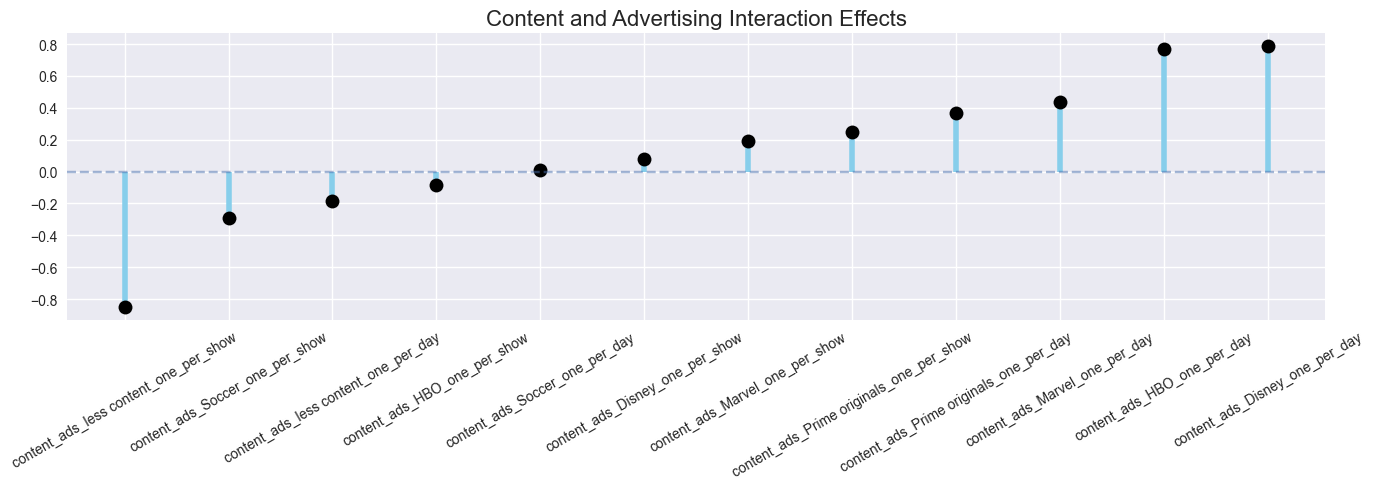

In [27]:
#Plot interaction lollipop 
plt.figure(figsize = (14,5))

markers, stems, baseline = plt.stem(attributes,
                                    utilities,
                                    linefmt = '-',
                                    markerfmt = 'o',
                                    basefmt = ' ')

#Customize appearance
plt.setp(stems, color = "skyblue", linewidth = 4)
plt.setp(markers, color = "black", markersize = 10)

#Title
plt.title('Content and Advertising Interaction Effects', fontsize = 16)

#Axis formatting
plt.xticks(rotation = 30)

#Horizontal reference line
plt.axhline(y=0, linestyle='--', alpha=0.5)

#Layout optimization
plt.tight_layout()

plt.savefig('../visuals/content_ad_interaction_effects.png',
            bbox_inches='tight',
            dpi=300)

plt.show()

---

# Conclusion and Business Insights

This project used conjoint analysis to evaluate which Netflix subscription features have the strongest influence on customer preferences and decision-making.

### Key Findings

- Subscription pricing had a major impact on customer choice behavior.
- Certain premium content offerings produced higher customer utility scores.
- Higher advertisement exposure generally reduced customer preference.
- The interaction analysis indicated that customers may be more accepting of ads when bundled with more attractive content options.

### Business Implications

The analysis suggests that Netflix can improve its subscription strategy by finding the right balance between:

- competitive pricing,
- premium content offerings,
- and advertisement levels.

Understanding these customer trade-offs can help support better pricing decisions, increase subscription appeal, and improve overall customer satisfaction.

### Future Improvements

This project can be extended further by incorporating:

- larger and more realistic datasets,
- customer segmentation analysis,
- advanced conjoint modeling techniques,
- and predictive simulations for subscription optimization.

# Limitations of the Analysis

This conjoint analysis has several limitations that should be considered when interpreting the results.

### Market Conditions
The model assumes relatively stable market conditions and customer behavior over time. External factors such as inflation, economic downturns, increased competition, or changes in streaming demand could influence customer preferences differently in real-world scenarios.

### Survey Design Constraints
The results are also limited to the subscription options included in the survey dataset. Different pricing levels, additional content bundles, or new subscription combinations could lead to different customer utility estimates and feature importance results.

Because of this, survey design plays a critical role in conjoint analysis. The quality and relevance of the selected feature combinations directly affect the insights generated by the model.


# Project Information

**Author:** Faraz Ibrahim

**Project:** Choice-Based Conjoint Analysis of Netflix Subscription Preferences

**Type:** Data Science / Marketing Analytics Project

**Tools:** Python, Pandas, Statsmodels, Matplotlib

**Dated:** 7 May 2026